In [1]:
## page 40 예제 
import warnings ;warnings.filterwarnings('ignore')
import sys ;sys.path.append("../../")
from  CommonFunc_04 import *
DataPreprocessing.plotSetting(setting_info=True)
import tensorflow as tf
print(yellow(f"tensorflow version : {tf.__version__}"))
import tensorflow as tf, numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import keras

  ⁍ 현재 경로의 폴더 목록 --
  폴더1 :  /Users/forrestdpark/Desktop/PDG/DailyHelloWorld_/개발자를위한머신러닝/__pycache__
../ +  ../../ 경로 python path 에 추가. 
◎ 주피터 가상환경  : base
◎ Python 설치 경로:/opt/anaconda3/bin/python
◎ Graph 한글화 Setting
패키지 목록이 package_list.txt 파일에 저장되었습니다.
  - ◎ matplot graph set complete
tensorflow version : 2.16.1


---
# Chapter 3. 고급 컴퓨터 비전 CNN

In [2]:
## Call back 을 이용해서 에포크 수를 자동으로 맞춰주자. 
callbacks = callback_setting(percent=0.85)
mnist = tf.keras.datasets.fashion_mnist

(training_images,training_labels),(test_images,test_labels)\
=mnist.load_data()
    
## 이미지 reshape ,정규화 
training_images =training_images.reshape(60000,28,28,1)
training_images= training_images/255.0
test_images = test_images.reshape(10000,28,28,1)
test_images = test_images/255.0

## 모델 컴파일 
model = tf.keras.models.Sequential([
    ## Convolution , maxpooling filter apply 
    tf.keras.layers.Conv2D(64,(3,3),activation = 'relu',input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation ='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    ### 2D-> 1D flatten
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation = tf.nn.relu),
    tf.keras.layers.Dense(10,activation = tf.nn.softmax)
])

model.compile(optimizer='adam',
            loss = 'sparse_categorical_crossentropy',
            metrics= ['accuracy']
            )
model.fit(training_images,training_labels, epochs=50, callbacks=[callbacks])
evaluate_model(model,test_data=test_images,test_label=test_labels)


Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.7807 - loss: 0.6110
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8908 - loss: 0.3018
 정확도 85.0% 에 도달하여 훈련을 멈춥니다.!!
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.8908 - loss: 0.3018
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
1번째이미지는 99.14%확률로 9입니다.
2번째이미지는 99.98%확률로 2입니다.
3번째이미지는 100.00%확률로 1입니다.
4번째이미지는 100.00%확률로 1입니다.
5번째이미지는 81.14%확률로 6입니다.
6번째이미지는 99.99%확률로 1입니다.
7번째이미지는 89.90%확률로 4입니다.
8번째이미지는 85.94%확률로 6입니다.
9번째이미지는 97.22%확률로 5입니다.
10번째이미지는 99.99%확률로 7입니다.


In [3]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 731,360 (2.79 MB)

 Trainable params: 243,786 (952.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 487,574 (1.86 MB)

In [4]:
a=(3,3)
a[0]*a[1]

9

In [19]:
def calc_parameter_number_by_cnn():
    conv_1_num = 64
    conv_1_size= 3*3
    conv_1_param = conv_1_num*conv_1_size+conv_1_num
    print("1st conv2D layer parameter calc :")
    print(yellow(f"\tX({conv_1_num}) * m({conv_1_size})+ c({conv_1_num})= Y({conv_1_param})"))
    print(blue(f"\t필터개수({conv_1_num}) * 필터당 가중치수({conv_1_size})+ 필터개수*필터당 절편({conv_1_num}*1)=총개수({conv_1_param})"))
    
    conv_1_num = 64
    conv_1_size= 3*3
    conv_1_param = conv_1_num*conv_1_size+conv_1_num
    print("1st conv2D layer parameter calc :")
    print(yellow(f"\tX({conv_1_num}) * m({conv_1_size})+ c({conv_1_num})= Y({conv_1_param})"))
    print(blue(f"\t필터개수({conv_1_num}) * 필터당 가중치수({conv_1_size})+ 필터개수*필터당 절편({conv_1_num}*1)=총개수({conv_1_param})"))
calc_parameter_number_by_cnn()
    

1st conv2D layer parameter calc :
	X(64) * m(9)+ c(64)= Y(640)
	필터개수(64) * 필터당 가중치수(9)+ 필터개수*필터당 절편(64*1)=총개수(640)


---
## 3.5 말과 사람 구분하는 모델


## homebrew 로 wget 설치후 실행할것
!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/horse-or-human.zip \
    -O /Users/forrestdpark/horse-or-human.zip

- 데스크탑에 파일 다운

--2024-10-14 08:35:34--  https://storage.googleapis.com/learning-datasets/horse-or-human.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 34.64.4.59, 34.64.4.27, 34.64.4.91, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|34.64.4.59|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 149574867 (143M) [application/zip]
Saving to: ‘/Users/forrestdpark/horse-or-human.zip’

/Users/forrestdpark 100%[===================>] 142.65M  8.34MB/s    in 18s     

2024-10-14 08:35:52 (8.13 MB/s) - ‘/Users/forrestdpark/horse-or-human.zip’ saved [149574867/149574867]



In [29]:
# import os
# import zipfile

# local_zip = '/Users/forrestdpark/CNN_horse-or-human/horse-or-human.zip'
# zip_ref = zipfile.ZipFile(local_zip, 'r')
# zip_ref.extractall('/Users/forrestdpark/CNN_horse-or-human/horse-or-human')
# zip_ref.close()


In [70]:

from pprint import pprint
training_dir = '/Users/forrestdpark/CNN_horse-or-human/horse-or-human/'
train_horse_dir =os.path.join(training_dir,'horses')
train_human_dir =os.path.join(training_dir,'humans')
print(train_horse_dir)

train_horse_names =os.listdir(train_horse_dir)
pprint(train_horse_names[:3])
train_human_names =os.listdir(train_human_dir)
pprint(train_human_names[:3])

print(yellow(f'total training horse images : {len(train_horse_names)}'))
print(yellow(f'total training human images : {len(train_human_names)}'))

/Users/forrestdpark/CNN_horse-or-human/horse-or-human/horses
['horse43-5.png', 'horse06-5.png', 'horse20-6.png']
['human17-22.png', 'human10-17.png', 'human10-03.png']
total training horse images : 500
total training human images : 527


In [45]:
## picture showing 
import matplotlib.pyplot as plt
import matplotlib.image as mpimage

# 4x4 pictures 
nrows = 4
ncols = 4
pic_index = 0

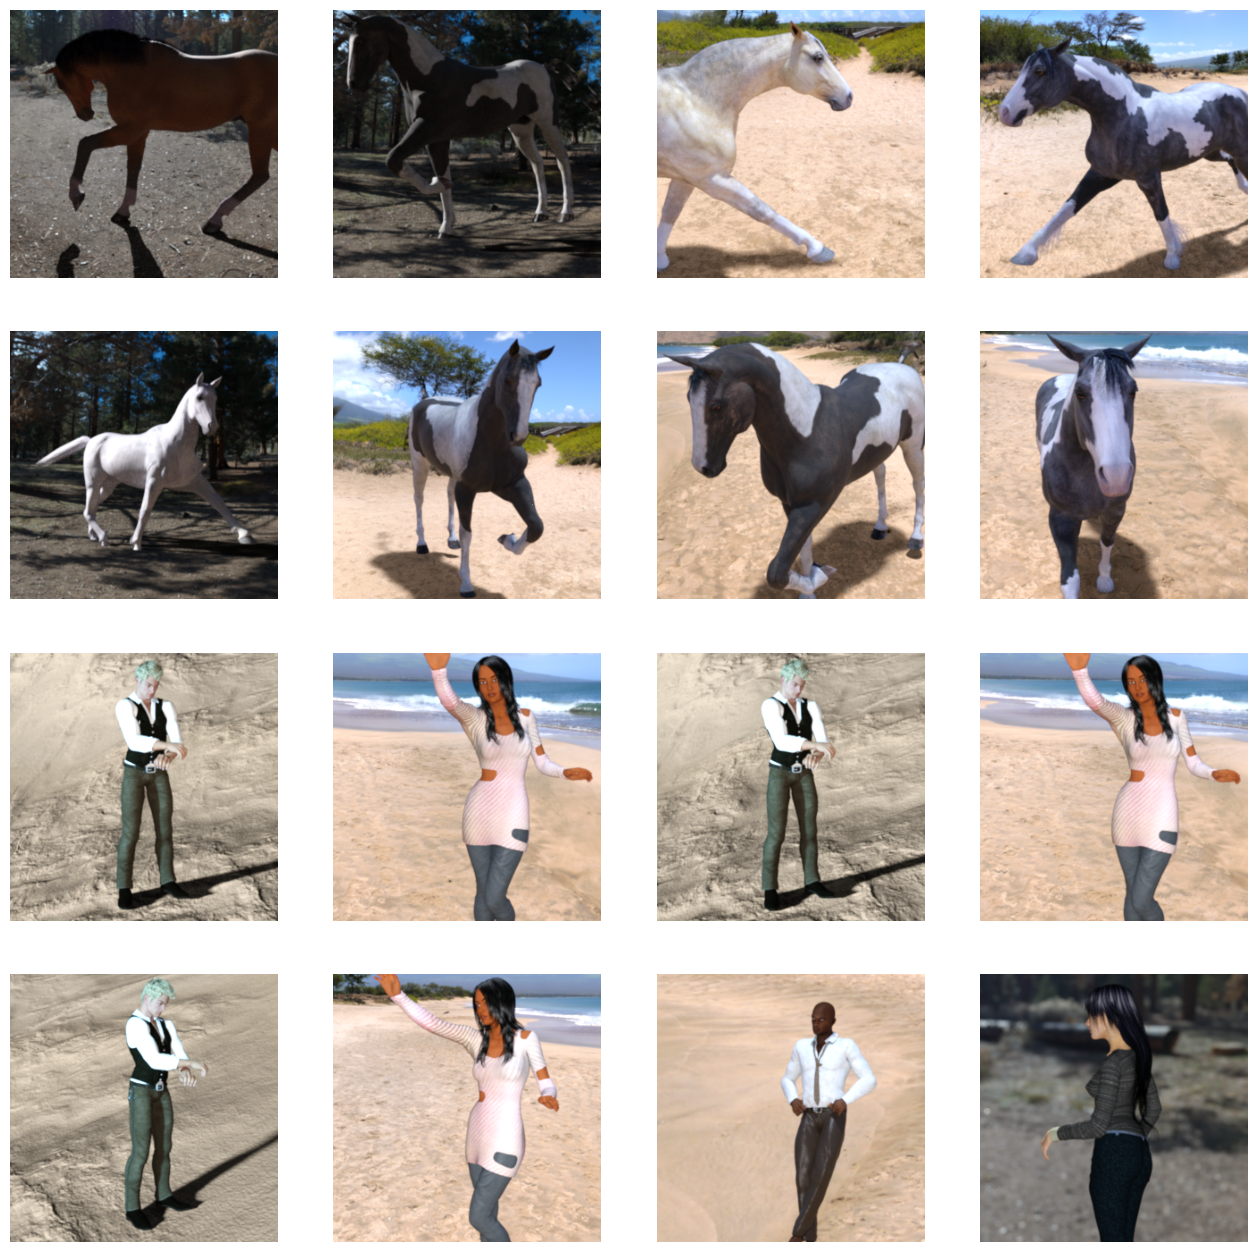

In [51]:


fig = plt.gcf()
fig.set_size_inches(ncols*4, nrows*4)
pic_index +=8
next_horse_pix = [os.path.join(train_horse_dir,fname) for fname in train_horse_names[pic_index-8:pic_index]]
next_human_pix = [os.path.join(train_human_dir,fname) for fname in train_human_names[pic_index-8:pic_index]]


for i, img_path in enumerate(next_horse_pix+next_human_pix):
    # print(img_path)
    sp = plt.subplot(nrows,nrows,i+1)
    sp.axis('off')
    img = mpimage.imread(img_path)
    plt.imshow(img)
plt.show()



In [72]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## 전체 이미지 정규화 
train_datagen = ImageDataGenerator(rescale=1/255)

## training generator 로 training data 만들기 
train_generator = train_datagen.flow_from_directory(
    training_dir,
    target_size=(300,300),## image size 
    # batch_size =128,
    class_mode ='binary' ## horse, human 두종류
    
)


Found 1027 images belonging to 2 classes.


## CNN model 만들기

In [55]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16,(3,3),activation='relu',
                        input_shape =(300,300,3)), ## rgb 세개의 층
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(32,(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

In [56]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 298, 298, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 149, 149, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 147, 147, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 33, 33, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,704,097 (6.50 MB)

 Trainable params: 1,704,097 (6.50 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
from tensorflow.keras.optimizers import RMSprop
model.compile(loss = 'binary_crossentropy',
              optimizer = RMSprop(learning_rate= 0.001),
              metrics = ['accuracy']
              )

In [60]:
model.fit(train_generator,epochs=15)

Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.4963 - loss: 0.7632
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.5921 - loss: 0.6587
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.6406 - loss: 0.6067
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.7767 - loss: 0.6778
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.8636 - loss: 0.3137
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.9288 - loss: 0.2093
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.7216 - loss: 1.0356
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.9608 - loss: 0.1065
Epoch 9/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.8698 - loss: 0.7723
Epoch 10/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.9584 - loss: 0.1177
Epoch 11/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.9765 - loss: 0.0715
Epoch 12/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.9746 - loss: 0.0651
Epoch 13/15
9

---
### Validation 



!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/validation-horse-or-human.zip \
    -O /Users/forrestdpark/CNN_horse-or-human/validation/validation-horse-or-human.zip

In [61]:

import os
import zipfile

local_zip = '/Users/forrestdpark/CNN_horse-or-human/validation/validation-horse-or-human.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/Users/forrestdpark/CNN_horse-or-human/validation/validation-horse-or-human')
zip_ref.close()


--2024-10-14 09:41:02--  https://storage.googleapis.com/learning-datasets/validation-horse-or-human.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 34.64.4.123, 34.64.4.27, 34.64.4.59, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|34.64.4.123|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11480187 (11M) [application/zip]
Saving to: ‘/Users/forrestdpark/CNN_horse-or-human/validation/validation-horse-or-human.zip’

/Users/forrestdpark 100%[===================>]  10.95M  5.76MB/s    in 1.9s    

2024-10-14 09:41:05 (5.76 MB/s) - ‘/Users/forrestdpark/CNN_horse-or-human/validation/validation-horse-or-human.zip’ saved [11480187/11480187]



In [71]:
validation_dir = '/Users/forrestdpark/CNN_horse-or-human/validation/validation-horse-or-human'

validation_datagen = ImageDataGenerator(rescale = 1/255)
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size =(300,300),
    class_mode = 'binary'
)

model.fit(train_generator,
          epochs =15,
          validation_data = validation_generator)


Found 256 images belonging to 2 classes.
Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9467 - loss: 0.1317 - val_accuracy: 0.7695 - val_loss: 3.4028
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9797 - loss: 0.1120 - val_accuracy: 0.8359 - val_loss: 1.8793
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9893 - loss: 0.0409 - val_accuracy: 0.8477 - val_loss: 2.5427
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9746 - loss: 0.0941 - val_accuracy: 0.8555 - val_loss: 1.6224
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9933 - loss: 0.0282 - val_accuracy: 0.8398 - val_loss: 2.1571
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9841 - loss: 0.1057 - val_accuracy: 0.8398 - val_loss: 2.2847
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.8398 - val_loss: 2.9482
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9887 - loss: 